<a href="https://colab.research.google.com/github/areesha-del/AI-ML-Hands-on/blob/main/CLASSIFICATION_SUPERVISED_MODEL_FOR_DESCRETE_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CLASSIFICATION SUPERVISED MODEL FOR DESCRETE DATA**

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# 1. Load dataset
df = pd.read_csv("/content/Admission.csv")

# 2. Clean column names
df.columns = df.columns.str.strip()

# 3. Convert target to binary (discrete classification)
df["Chance of Admit"] = (df["Chance of Admit"] >= 0.5).astype(int)

# 4. Features and target
X = df.drop("Chance of Admit", axis=1)
y = df["Chance of Admit"]

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature scaling (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Models (KNN replaced with SVM)
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# 8. Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-Score :", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Logistic Regression
Accuracy : 0.925
Precision: 0.9466666666666667
Recall   : 0.9726027397260274
F1-Score : 0.9594594594594594
Confusion Matrix:
 [[ 3  4]
 [ 2 71]]

Support Vector Machine
Accuracy : 0.925
Precision: 0.9240506329113924
Recall   : 1.0
F1-Score : 0.9605263157894737
Confusion Matrix:
 [[ 1  6]
 [ 0 73]]

Decision Tree
Accuracy : 0.8625
Precision: 0.918918918918919
Recall   : 0.9315068493150684
F1-Score : 0.9251700680272109
Confusion Matrix:
 [[ 1  6]
 [ 5 68]]


In [ ]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

n = 300

# Create dataset
df = pd.DataFrame({
    "MonthlyUsageHours": np.random.normal(60, 20, n).clip(5, 120).round(1),
    "MonthlyBillPKR": np.random.normal(2500, 800, n).clip(500, 6000).round(0),
    "Complaints": np.random.poisson(1.2, n).clip(0, 6),
    "TenureMonths": np.random.randint(1, 60, n),
    "ContractType": np.random.choice(["Monthly", "Yearly"], n, p=[0.7, 0.3])
})

# Display dataset info
print(df.head())
print("\nShape:", df.shape)
print("\nSummary:")
print(df.describe(include="all"))


   MonthlyUsageHours  MonthlyBillPKR  Complaints  TenureMonths ContractType
0               69.9          1837.0           0            47      Monthly
1               57.2          2052.0           3            43      Monthly
2               73.0          3098.0           1            50       Yearly
3               90.5          2988.0           1            23      Monthly
4               55.3          2483.0           2            44      Monthly

Shape: (300, 5)

Summary:
        MonthlyUsageHours  MonthlyBillPKR  Complaints  TenureMonths  \
count          300.000000      300.000000  300.000000    300.000000   
unique                NaN             NaN         NaN           NaN   
top                   NaN             NaN         NaN           NaN   
freq                  NaN             NaN         NaN           NaN   
mean            59.863000     2482.793333    1.183333     28.636667   
std             19.383106      769.292593    1.149257     16.686505   
min              5.0

In [ ]:
# Create churn label (hidden rule + noise)
score = (
    0.04*(df["MonthlyBillPKR"] - 2500) +
    0.8*(df["Complaints"]) -
    0.03*(df["TenureMonths"]) +
    1.2*(df["ContractType"] == "Monthly").astype(int) -
    0.02*(df["MonthlyUsageHours"] - 60)
)

prob = 1 / (1 + np.exp(-score/10))
df["Churn"] = (np.random.rand(n) < prob).astype(int)  # 1=Yes, 0=No

df.head()





,MonthlyUsageHours,MonthlyBillPKR,Complaints,TenureMonths,ContractType,Churn
0,69.9,1837.0,0,47,Monthly,0
1,57.2,2052.0,3,43,Monthly,0
2,73.0,3098.0,1,50,Yearly,1
3,90.5,2988.0,1,23,Monthly,1
4,55.3,2483.0,2,44,Monthly,1


In [ ]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop("Churn", axis=1)
y = df["Churn"]

cat_cols = ["ContractType"]
num_cols = ["MonthlyUsageHours", "MonthlyBillPKR", "Complaints", "TenureMonths"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tree_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_model.fit(X_train, y_train)
pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_tree))
print(confusion_matrix(y_test, pred_tree))
print(classification_report(y_test, pred_tree))

Decision Tree Accuracy: 0.7466666666666667
[[31  8]
 [11 25]]
              precision    recall  f1-score   support

           0       0.74      0.79      0.77        39
           1       0.76      0.69      0.72        36

    accuracy                           0.75        75
   macro avg       0.75      0.74      0.75        75
weighted avg       0.75      0.75      0.75        75



In [ ]:
clf = tree_model.named_steps["clf"]
feature_names = tree_model.named_steps["prep"].get_feature_names_out()

imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top Important Features:\n", imp.head(8))

Top Important Features:
 num__MonthlyBillPKR         0.910189
num__TenureMonths           0.048323
num__Complaints             0.023654
num__MonthlyUsageHours      0.017834
cat__ContractType_Yearly    0.000000
dtype: float64


In [ ]:
from sklearn.tree import _tree

def explain_tree_decision(pipeline, single_row):
    prep = pipeline.named_steps["prep"]
    clf = pipeline.named_steps["clf"]
    X_trans = prep.transform(single_row)

    node_indicator = clf.decision_path(X_trans)
    leave_id = clf.apply(X_trans)

    feature_names = prep.get_feature_names_out()

    print("Customer input:\n", single_row.to_string(index=False), "\n")
    print("Decision path (rules):")
    for node_id in node_indicator.indices:
        if leave_id[0] == node_id:
            continue

        feature = clf.tree_.feature[node_id]
        threshold = clf.tree_.threshold[node_id]

        if feature != _tree.TREE_UNDEFINED:
            fname = feature_names[feature]
            val = X_trans[0, feature]
            if val <= threshold:
                print(f"- {fname} = {val:.3f} <= {threshold:.3f}  → go LEFT")
            else:
                print(f"- {fname} = {val:.3f} >  {threshold:.3f}  → go RIGHT")

    proba = pipeline.predict_proba(single_row)[0]
    pred = pipeline.predict(single_row)[0]
    print("\nPrediction:", "Churn" if pred==1 else "No Churn")
    print("Probabilities [NoChurn, Churn]:", proba)

# pick one test sample
sample = X_test.sample(1, random_state=1)
explain_tree_decision(tree_model, sample)

Customer input:
  MonthlyUsageHours  MonthlyBillPKR  Complaints  TenureMonths ContractType
              75.5          2163.0           0            36       Yearly 

Decision path (rules):
- num__MonthlyBillPKR = 2163.000 <= 2518.500  → go LEFT
- num__MonthlyBillPKR = 2163.000 >  2149.500  → go RIGHT
- num__MonthlyBillPKR = 2163.000 >  2162.000  → go RIGHT
- num__TenureMonths = 36.000 >  6.500  → go RIGHT

Prediction: No Churn
Probabilities [NoChurn, Churn]: [0.75757576 0.24242424]


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

svm_model = Pipeline(steps=[
    ("prep", preprocess),
    ("scale", StandardScaler(with_mean=False)),  # sparse-safe
    ("clf", SVC(kernel="rbf", C=5, gamma="scale", probability=True))
])

svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)

print("SVM (RBF) Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

SVM (RBF) Accuracy: 0.7866666666666666
[[33  6]
 [10 26]]
              precision    recall  f1-score   support

           0       0.77      0.85      0.80        39
           1       0.81      0.72      0.76        36

    accuracy                           0.79        75
   macro avg       0.79      0.78      0.78        75
weighted avg       0.79      0.79      0.79        75



In [ ]:
sample2 = X_test.sample(1, random_state=7)
proba2 = svm_model.predict_proba(sample2)[0]
pred2 = svm_model.predict(sample2)[0]
print(sample2)
print("\nPrediction:", "Churn" if pred2==1 else "No Churn")
print("Probabilities [NoChurn, Churn]:", proba2)

     MonthlyUsageHours  MonthlyBillPKR  Complaints  TenureMonths ContractType
150               65.0          2450.0           0            46      Monthly

Prediction: No Churn
Probabilities [NoChurn, Churn]: [0.50648956 0.49351044]


In [ ]:
# Task 1: Problem Understanding (Readmission Prediction)

import pandas as pd

# -------------------------------
# Step 1: Load healthcare dataset
# -------------------------------
# Example: Diabetes Readmission Dataset (UCI / Kaggle style)
# Replace path with your actual dataset file
df = pd.read_csv("/content/train_df.csv")

# Display first few rows
print("Dataset Preview:")
print(df.head())

# -------------------------------
# Step 2: Define the target variable
# -------------------------------
# Assume column 'readmitted' has values:
# '<30'  → readmitted within 30 days
# '>30' or 'NO' → not readmitted within 30 days

# Convert to binary classification labels
df['Readmission_Risk'] = df['readmitted'].apply(
    lambda x: "High Risk" if x == "<30" else "Low Risk"
)

# -------------------------------
# Step 3: Verify classification nature
# -------------------------------
print("\nTarget Class Distribution:")
print(df['Readmission_Risk'].value_counts())


Dataset Preview:
   age  gender primary_diagnosis  num_procedures  days_in_hospital  \
0   69    Male     Heart Disease               1                 2   
1   32  Female              COPD               2                13   
2   89    Male          Diabetes               1                 7   
3   78    Male              COPD               9                 2   
4   38    Male          Diabetes               6                 4   

   comorbidity_score              discharge_to  readmitted  
0                  1          Home Health Care           0  
1                  2   Rehabilitation Facility           0  
2                  1                      Home           0  
3                  2  Skilled Nursing Facility           0  
4                  4   Rehabilitation Facility           0  

Target Class Distribution:
Readmission_Risk
Low Risk    5000
Name: count, dtype: int64

Task 1 Completed: Problem framed as Binary Classification


In [ ]:
# ============================================
# Hospital Readmission Risk Prediction
# Decision Tree & SVM (RBF Kernel)
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

# --------------------------------------------
# Load Dataset
# --------------------------------------------
df = pd.read_csv("/content/train_df.csv")

# --------------------------------------------
# Create Target Variable (Readmission Risk)
# High risk = older age, longer stay, more diseases
# --------------------------------------------
risk_score = (
    0.03 * df['age'] +
    0.5 * df['comorbidity_score'] +
    0.2 * df['num_procedures'] +
    0.15 * df['days_in_hospital']
)

threshold = np.percentile(risk_score, 65)
df['ReadmissionRisk'] = np.where(risk_score >= threshold, 1, 0)
# 1 = High Risk, 0 = Low Risk

# --------------------------------------------
# Feature Selection
# --------------------------------------------
features = [
    'age',
    'days_in_hospital',
    'num_procedures',
    'comorbidity_score',
    'primary_diagnosis'
]

X = df[features]
y = df['ReadmissionRisk']

# --------------------------------------------
# Encode Categorical Feature
# --------------------------------------------
le = LabelEncoder()
X['primary_diagnosis'] = le.fit_transform(X['primary_diagnosis'])

# --------------------------------------------
# Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ============================================
# DECISION TREE MODEL
# ============================================
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DECISION TREE RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Feature Importance (Decision Tree Explanation)
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nDecision Tree Feature Importance:")
print(dt_importance)

# ============================================
# SVM (RBF KERNEL)
# ============================================

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("\nSVM (RBF) RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# ============================
# SVM (RBF) - FIXED VERSION
# ============================

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (IMPORTANT FIX)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Train SVM
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm.predict(X_test_scaled)

print("\nSVM (RBF) RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# ============================
# SVM Internal Explanation
# ============================

perm = permutation_importance(
    svm,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

svm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nSVM Feature Importance:")
print(svm_importance)


/tmp/ipython-input-1135758846.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['primary_diagnosis'] = le.fit_transform(X['primary_diagnosis'])


DECISION TREE RESULTS
Accuracy: 0.8904
Confusion Matrix:
 [[751  61]
 [ 76 362]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       812
           1       0.86      0.83      0.84       438

    accuracy                           0.89      1250
   macro avg       0.88      0.88      0.88      1250
weighted avg       0.89      0.89      0.89      1250


Decision Tree Feature Importance:
             Feature  Importance
3  comorbidity_score    0.304613
1   days_in_hospital    0.240212
2     num_procedures    0.234592
0                age    0.220583
4  primary_diagnosis    0.000000

SVM (RBF) RESULTS
Accuracy: 0.9816
Confusion Matrix:
 [[805   7]
 [ 16 422]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       812
           1       0.98      0.96      0.97       438

    accuracy                           0.98      1250
   macro avg       0.98      0.98      0.98      1250
weighted 

In [ ]:
# ==========================================
# Hospital Readmission Prediction
# Decision Tree & SVM (Simple & Safe)
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------
# Load Dataset
# ------------------------------------------
df = pd.read_csv("/content/hospital_readmissions.csv")

print("Dataset loaded:", df.shape)

# ------------------------------------------
# Target Encoding (SAFE & CORRECT)
# ------------------------------------------
df['readmitted'] = df['readmitted'].replace({
    '<30': 1,    # High Risk
    'NO': 0,     # Low Risk
    '>30': 0    # Low Risk
})

# Drop missing values
df = df.dropna()

# ------------------------------------------
# Separate Features and Target
# ------------------------------------------
X = df.drop(columns=['readmitted'])
y = df['readmitted']

# ------------------------------------------
# Encode ALL categorical columns
# ------------------------------------------
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# ------------------------------------------
# Train-Test Split (NO STRATIFY → NO ERROR)
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ==========================================
# DECISION TREE MODEL
# ==========================================
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n===== DECISION TREE RESULTS =====")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

# ==========================================
# SVM MODEL (RBF)
# ==========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("\n===== SVM (RBF) RESULTS =====")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Dataset loaded: (25000, 17)

===== DECISION TREE RESULTS =====
Accuracy: 0.60368
Confusion Matrix:
 [[2298 1020]
 [1457 1475]]
              precision    recall  f1-score   support

          no       0.61      0.69      0.65      3318
         yes       0.59      0.50      0.54      2932

    accuracy                           0.60      6250
   macro avg       0.60      0.60      0.60      6250
weighted avg       0.60      0.60      0.60      6250


===== SVM (RBF) RESULTS =====
Accuracy: 0.616
Confusion Matrix:
 [[2511  807]
 [1593 1339]]
              precision    recall  f1-score   support

          no       0.61      0.76      0.68      3318
         yes       0.62      0.46      0.53      2932

    accuracy                           0.62      6250
   macro avg       0.62      0.61      0.60      6250
weighted avg       0.62      0.62      0.61      6250



Target classes: [0 1 2]

Decision Tree Accuracy: 0.5344827586206896
              precision    recall  f1-score   support

           0       0.20      0.14      0.17         7
           1       0.63      0.61      0.62        28
           2       0.50      0.57      0.53        23

    accuracy                           0.53        58
   macro avg       0.44      0.44      0.44        58
weighted avg       0.53      0.53      0.53        58



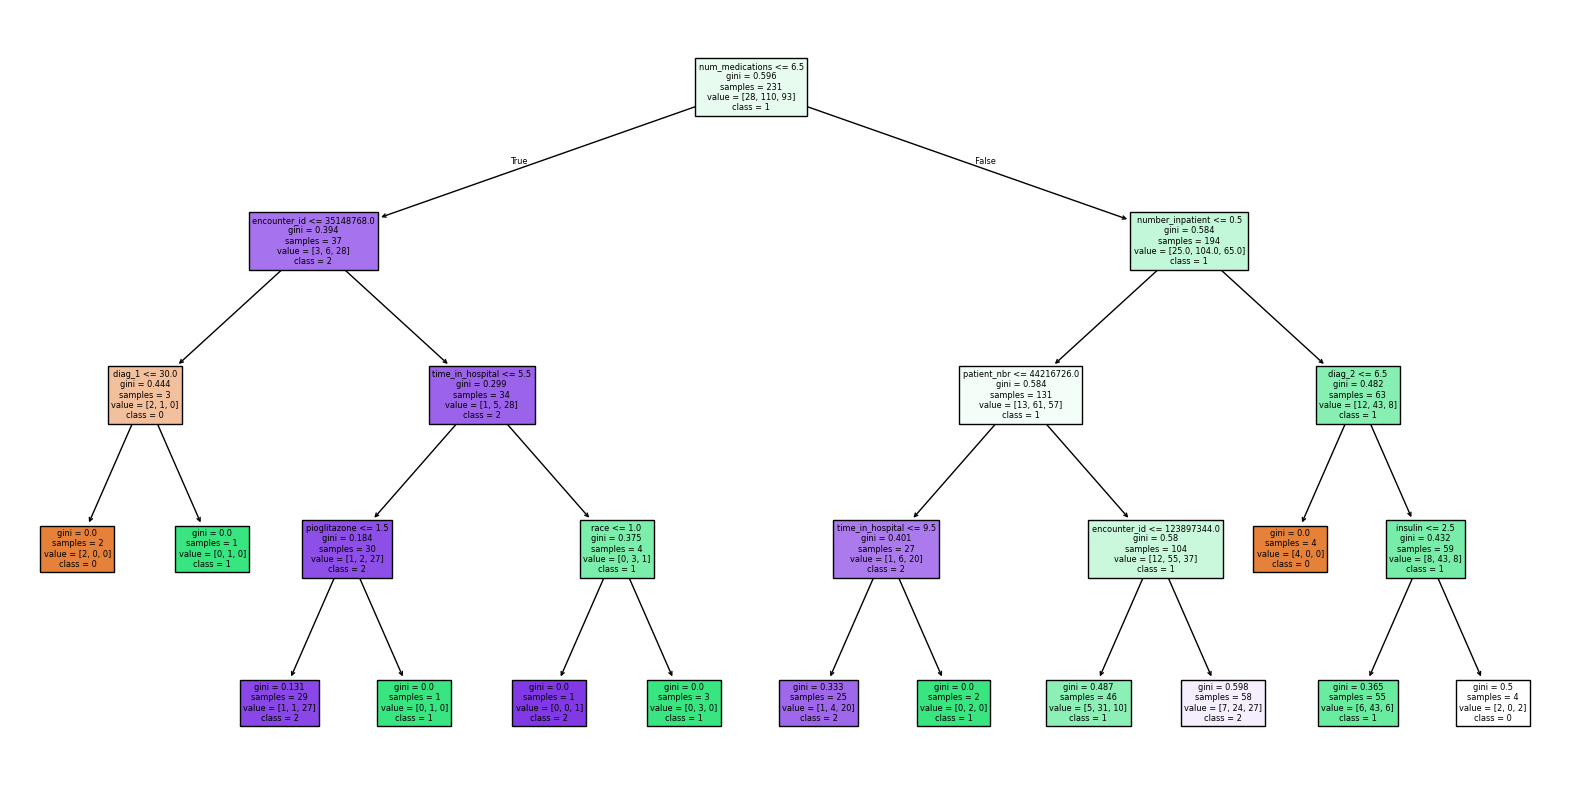


SVM Accuracy: 0.41379310344827586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.46      0.68      0.55        28
           2       0.29      0.22      0.25        23

    accuracy                           0.41        58
   macro avg       0.25      0.30      0.27        58
weighted avg       0.34      0.41      0.37        58



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


# ===============================
# 2. Load Dataset
# ===============================
data = pd.read_csv("/content/diabetic_data.csv")


# ===============================
# 3. Data Cleaning (SAFE)
# ===============================

# Replace '?' with NaN
data.replace("?", np.nan, inplace=True)

# Drop columns with too many missing values
data.drop(columns=[
    "weight",
    "payer_code",
    "medical_specialty"
], inplace=True)

# Drop remaining rows with missing values
data.dropna(inplace=True)


# ===============================
# 4. Encode Categorical Data
# ===============================
label_encoders = {}
for col in data.select_dtypes(include="object").columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


# ===============================
# 5. Features & Target
# ===============================
X = data.drop("readmitted", axis=1)
y = data["readmitted"]

# ✅ CHECK: ensure more than one class
print("Target classes:", y.unique())


# ===============================
# 6. Train-Test Split (FIXED)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # ✅ prevents ValueError
)


# ===============================
# 7. Decision Tree
# ===============================
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


# ===============================
# 8. Decision Tree Visualization
# ===============================
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True
)
plt.show()


# ===============================
# 9. SVM Model
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("\nSVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
